1. წარმოადგინეთ შესრულებული სამუშაოს ანგარიში GitHub-ში readme ფაილის სახით. (1 ქულა)
2. ანგარიშში უნდა იყოს ბმული მოვლენათა ფაილზე (რომელიც უნდა იყოს ატვირთული GitHub-ში) და DDoS
შეტევის დრო მითითებული. (1 ქულა)
3. ანგარიშში უნდა იყოს განხილული თქვენს მიერ დაწერილი და GitHub-ში ატვირთული კოდის
მნიშვნელოვანი ფრაგმენტები. (1 ქულა)
4. ანგარიში აუცილებლად უნდა შეიცავდეს თვალსაჩინოებას გრაფიკის ან დიაგრამის სახით. უნდა ჩანდეს
რეგრესიული ანალიზის ჩატარება. ანგარიში უნდა იკითხებოდეს ადვილად და უნდა იყოს მარტივად გასაგები
მკითხველისთვის. მკითხველმა მარტივად უნდა შეძლოს თქვენს მიერ შესრულებული სამუშაოს გამეორება
ანგარიშის წაკითხვის შედეგად. (2 ქულა)

In [7]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Log file path
log_file = "daviti_datunashvili_1_server.log"

# Regular expression to extract IP, timestamp, and request type
log_pattern = re.compile(r"(\d+\.\d+\.\d+\.\d+) - - \[(.*?)\] \"(\w+) ")

# Parsing log file
data = []
with open(log_file, "r", encoding="utf-8") as file:
    for line in file:
        match = log_pattern.search(line)
        if match:
            ip, timestamp, method = match.groups()
            data.append((ip, timestamp, method))

# Convert to DataFrame
df = pd.DataFrame(data, columns=["IP", "Timestamp", "Method"])


# პოტენციური შეტევების დრო და რაოდენობა

In [6]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"], format="%Y-%m-%d %H:%M:%S%z")

df.set_index("Timestamp", inplace=True)
time_counts = df.resample("T").count()["IP"]


ddos_time = time_counts.idxmax()
ddos_count = time_counts.max()
f"შეტევის ხანგრძლივობა: {ddos_time}, შეტევების რაოდენობა: {ddos_count}"


KeyError: 'Timestamp'

In [8]:

# ტოპ 5 IP 
top_ips = Counter(df["IP"]).most_common(5)
top_ips


[('182.144.219.94', 542),
 ('37.233.86.88', 527),
 ('200.44.34.124', 518),
 ('136.95.229.226', 517),
 ('111.127.34.37', 511)]

# ტრაფიკის დროზე დამოკიდებულების გრაფიკი


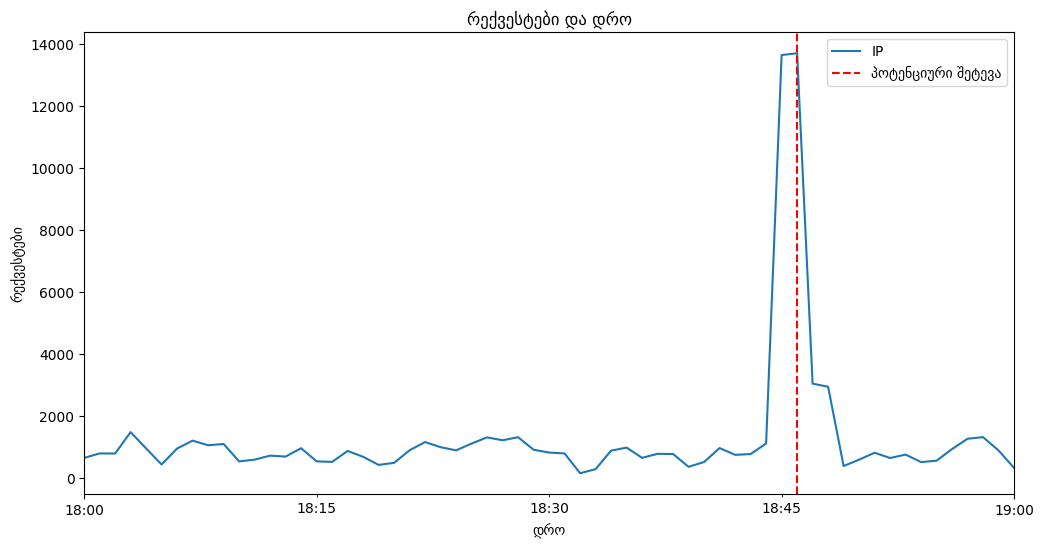

In [4]:

plt.figure(figsize=(12, 6))
time_counts.plot()
plt.axvline(ddos_time, color='r', linestyle='--', label="პოტენციური შეტევა")
plt.title("რექვესტები და დრო")
plt.xlabel("დრო")
plt.ylabel("რექვესტები")
plt.legend()
plt.show()
